# Scattering by multiple smooth **star-shaped** bodies at arbitrary positions and orientations

This notebook couples several smooth, star-shaped axisymmetric scatterers
$y=C_i+Q_i\,\big(\rho_i(\cos\theta)\,\hat r\big)$ — each with its own center
$C_i$ and orientation $Q_i$ — into one sound-hard Helmholtz scattering problem,
reusing every verified single-body ingredient of `starshape_bie.py`.  It is the
non-spherical counterpart of `Nspheres_offaxis.ipynb`.

Total-field formulation, identical in structure to the multi-sphere case:

$$u(x)=u^{inc}(x)+\sum_i D_i[u_i](x),\qquad
\Big[A_{ii}\,\delta_{ij}-(1-\delta_{ij})\,B_{ij}\Big]c=b,$$

with

$$A_{ii}=\tfrac12 M_i-K_i=\texttt{self\_operator(shape}_i),\qquad
B_{ij}=\big\langle Y_p^q,\;D_j[Y_n^m]\big\rangle_{S_i},\qquad
b^i=\texttt{incident\_trace\_projection}_i .$$

The single body operator $A_{ii}$ is **frame invariant** (it depends only on the
shape, because $K_i$'s kernel is a function of the local surface geometry and
$M_i$ is a local inner product); only the incident-wave right-hand side sees
$C_i,Q_i$.  The coupling block evaluates the source body's double layer at the
target body's $\theta$-slow/$\phi$-fast collocation nodes (mapped to global
coordinates) and projects onto $\overline{Y_p^q}$ with the **same** Galerkin
measure $W_{GL}\,W_i(\theta)$ that `self_operator` uses, so the whole block
system is one consistent Galerkin discretisation.  Each target node selects its
close-evaluation method automatically: plane-wave subtraction within a band of
the source surface, the rotated grid (or naive product-Gauss) beyond it.

Everything lives in the companion module `starmulti_bie.py`, which imports the
verified single-body machinery from `starshape_bie.py` unchanged.

**Tolerances.**  Validations 1 and the frame-invariance check compare against an
*analytic* reference (the exact multipole sphere solver, or an exact symmetry),
so their errors sit at the linear-solve / harmonic-evaluation floor
($\sim10^{-13}$).  Validation 2 (Green's representation) and the field plots are
limited by the close-evaluation quadrature floor at the chosen order; their
thresholds ($10^{-3}$ at $10^{-3}$ off a non-spherical surface, $10^{-2}$ for
the self-convergence of the solved field) are the documented quadrature
tolerances, in the style of the sphere notebook.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

import starshape_bie as ss
import starmulti_bie as sm
import multisphere_bie as msph
from offdiag_bie import SphereQuadrature
from essentials_bie import ComputeSphericalHarmonics

np.set_printoptions(precision=3, suppress=False)
t_start = time.time()
k = 2.0                                   # wavenumber used throughout


def rot(axis, ang):
    a = np.asarray(axis, float); a = a / np.linalg.norm(a)
    K = np.array([[0, -a[2], a[1]], [a[2], 0, -a[0]], [-a[1], a[0], 0]])
    return np.eye(3) + np.sin(ang) * K + (1 - np.cos(ang)) * (K @ K)


## Validation 1 — sphere limit: the new star-shape path vs the exact multipole solver

When every body is a `sphere`, the star-shape multi-body solver must reproduce
the arbitrary-center **exact-multipole** solver of `multisphere_bie.py` (whose
off-diagonal blocks are assembled from the analytic identity
$D[Y_n^m](x)=ik^2a^2 j_n'(ka)h_n^{(1)}(k|x-C|)Y_n^m$, with no quadrature).  Two
spheres in genuinely 3-D position (not on any coordinate axis) are solved by both
paths; the trace coefficients and a couple of exterior field values must agree at
the linear-solve floor.  This checks the entire star-shape coupling/assembly/field
pipeline against an independent implementation.

In [2]:
Nb1, q1 = 8, 24
a1, a2 = 1.0, 0.8
C1 = np.array([-0.7, 0.4, 0.2])
C2 = np.array([ 1.5, -0.6, 0.9])
print(f"surface gap = {np.linalg.norm(C2 - C1) - a1 - a2:.3f}")

# NEW star-shape multi-body path
bodies_s = [(ss.sphere(a1), C1, np.eye(3)), (ss.sphere(a2), C2, np.eye(3))]
c_star = sm.solve(bodies_s, Nb1, k, quad_order=q1)

# exact-multipole reference (multisphere_bie)
qsph = SphereQuadrature(q1)
c_ref = msph.solve(Nb1, k, [a1, a2], np.array([C1, C2]), qsph, method='exact')

err_coeff = max(np.max(np.abs(cs - cr)) for cs, cr in zip(c_star, c_ref))
pts1 = np.array([[3.0, 1.0, -0.5], [0.4, 2.0, 1.2], [-2.5, 0.3, 1.1]])
u_star = sm.total_field(pts1, bodies_s, c_star, Nb1, k, quad_order=q1)
u_ref = msph.total_field(pts1, Nb1, k, [a1, a2], np.array([C1, C2]), c_ref, qsph)
err_field = np.max(np.abs(u_star - u_ref) / np.abs(u_ref))
print(f"[1] star vs exact-multipole, trace coeffs : max abs err = {err_coeff:.3e}")
print(f"[1] star vs exact-multipole, field values : max rel err = {err_field:.3e}")
assert err_coeff < 1e-6
assert err_field < 1e-6

surface gap = 0.716


[1] star vs exact-multipole, trace coeffs : max abs err = 2.629e-14
[1] star vs exact-multipole, field values : max rel err = 4.043e-15


## Frame invariance of the single-body operator (headline consistency check)

The claim $A_{ii}=\texttt{self\_operator(shape}_i)$ is *frame invariant* is worth
testing physically.  Solve one **peanut** in two placements — (i) at the origin
with identity orientation and incidence $\hat z$, and (ii) translated to $C$ and
rotated by $Q$, with the incidence rotated to $Q\hat z$.  Because the operator
depends only on the shape while the RHS carries $(C,Q)$, the scattered fields must
be exactly covariant: $u_2(C+Q x)=u_1(x)$ at every exterior point.  (The diagonal
block itself is literally the same matrix in both solves, as `self_operator` takes
no $C,Q$; this test confirms the *rest* of the pipeline — RHS, coupling-free
single-body field evaluation — respects the same invariance.)

In [3]:
Nbf0, qf0 = 8, 24
peanut = ss.peanut()
Cf = np.array([0.6, -0.4, 0.9]); Qf = rot([0.4, 1.0, -0.2], 0.8)
zhat = np.array([0.0, 0.0, 1.0])

c_a = sm.solve([(peanut, np.zeros(3), np.eye(3))], Nbf0, k, quad_order=qf0)
c_b = sm.solve([(peanut, Cf, Qf)], Nbf0, k, direction=Qf @ zhat, quad_order=qf0)

# operator identity (same matrix regardless of placement)
A_a = ss.self_operator(peanut, Nbf0, k, quad_order=qf0)
A_b = ss.self_operator(peanut, Nbf0, k, quad_order=qf0)
print(f"[inv] self_operator frame invariance      : {np.max(np.abs(A_a - A_b)):.3e}")

pts0 = np.array([[2.0, 0.3, 0.4], [0.1, 1.8, -0.6], [-1.5, -1.0, 1.2]])
u1 = sm.total_field(pts0, [(peanut, np.zeros(3), np.eye(3))], c_a, Nbf0, k,
                    quad_order=qf0)
u2 = sm.total_field((Cf + pts0 @ Qf.T), [(peanut, Cf, Qf)], c_b, Nbf0, k,
                    direction=Qf @ zhat, quad_order=qf0)
# translating the body shifts the incident plane wave by a constant phase, so
# covariance reads u2(C + Q x) = exp(i k (Q zhat).C) * u1(x)
phase = np.exp(1j * k * ((Qf @ zhat) @ Cf))
err_cov = np.max(np.abs(u2 - phase * u1) / np.abs(u1))
print(f"[inv] rotation/translation covariance u2(C+Qx) vs u1(x): rel err = {err_cov:.3e}")
assert np.max(np.abs(A_a - A_b)) < 1e-13
assert err_cov < 1e-9

[inv] self_operator frame invariance      : 0.000e+00
[inv] rotation/translation covariance u2(C+Qx) vs u1(x): rel err = 4.581e-16


## The three-body geometry

The working configuration for the rest of the notebook: a **peanut**, a
**mushroom cap** and a **sphere** of radius $0.7$, each translated to a center off
every coordinate axis and given a distinct tilt $Q_i$, with moderate surface gaps
($\approx 0.25$–$0.58$).  The gaps are measured numerically (distance from a dense
sampling of one surface to the other body's surface).

In [4]:
mush = ss.mushroom_cap(); sph = ss.sphere(0.7)
Qp = rot([1, 0.5, 0.2], 0.7)
Qm = rot([0.3, 1, -0.4], -0.9)
Qs = rot([0.2, -0.3, 1], 1.3)
Cp = np.array([-1.05, -0.25, 0.15])
Cm = np.array([ 0.85, -0.20, -0.35])
Cs = np.array([ 0.00,  1.00,  0.50])
bodies = [(peanut, Cp, Qp), (mush, Cm, Qm), (sph, Cs, Qs)]
names = ["peanut", "mushroom", "sphere"]

from starshape_bie import _collocation, _geometry
def surf_gap(bi, bj):
    si, Ci, Qi = bi; sj, Cj, Qj = bj
    _, _, TH, PH, _, _, _, _ = _collocation(40)
    yl, _, _ = _geometry(si, TH, PH); Xg = Ci + yl @ Qi.T
    return sm.surface_distance(sj, (Xg - Cj) @ Qj).min()

for i in range(3):
    for j in range(i + 1, 3):
        g = surf_gap(bodies[i], bodies[j])
        print(f"  gap {names[i]}-{names[j]:8s}: {g:.3f}")
        assert g > 0.05, "bodies overlap or nearly touch"
print("geometry ready")


  gap peanut-mushroom: 0.576
  gap peanut-sphere  : 0.421
  gap mushroom-sphere  : 0.248
geometry ready


## Validation 2 — multi-body Green's representation with the real geometry

The most demanding geometric test.  Take a *manufactured* field
$u=\sum_i \Phi_{p_i}$, a sum of three point sources $\Phi_p(x)=e^{ik|x-p|}/4\pi|x-p|$,
one placed **inside** each body.  Such a $u$ is a radiating Helmholtz solution in
the exterior of all three bodies, so the exterior Green representation holds:

$$u(x)=\sum_i\Big(D_i[u|_{S_i}](x)-S_i[\partial_\nu u|_{S_i}](x)\Big),\qquad x\ \text{exterior},$$

with $\nu$ the outward normal of body $i$.  We project the trace of $u$ onto the
$Y_n^m$ (pointwise, solid-angle weight) for the double layer, feed the exact
$\partial_\nu u$ to the single layer (`slp_density_targets`, whose density callback
receives *local-frame* $(y,\nu)$ — mapped to global here), and check that the sum
reproduces $u$ at exterior points, **including one within $10^{-3}$ of each
surface**.  This exercises every geometric ingredient of the coupled system —
rotated grids, close evaluation between bodies, both layer potentials, and the
orientation maps.

The far points converge with $N_b$ (trace truncation); the near points are limited
by the close-evaluation quadrature floor at $10^{-3}$ off a *non-spherical*
surface, $\sim6\times10^{-4}$ relative here — hence the $10^{-3}$ threshold.

In [5]:
Nb2, q2 = 12, 36
p_local = [np.array([0.10, 0.00, 0.20]),
           np.array([0.00, 0.10, -0.10]),
           np.array([0.05, 0.05, 0.00])]
psrc = [C + Q @ pl for (s, C, Q), pl in zip(bodies, p_local)]
assert np.all(sm.interior_mask(bodies, np.array(psrc))), "a source is not inside its body"

def u_exact(X):
    X = np.atleast_2d(X)
    return sum(np.exp(1j * k * np.linalg.norm(X - p, axis=1))
               / (4 * np.pi * np.linalg.norm(X - p, axis=1)) for p in psrc)

def gradPhi(X, p):
    d = X - p; r = np.linalg.norm(d, axis=-1, keepdims=True)
    G = np.exp(1j * k * r) / (4 * np.pi * r)
    return G * (1j * k - 1 / r) * d / r

# pointwise Y_n^m coefficients of the trace on each body (solid-angle weight)
N, M, THETA, PHI, W_GL, S, T, ws = _collocation(q2)
Ycol, _, _ = ComputeSphericalHarmonics(Nb2, THETA, PHI)
ortho = np.max(np.abs((Ycol.conj().T * W_GL) @ Ycol - np.eye(Nb2 * Nb2)))
print(f"[2] sphere-projection orthonormality       : {ortho:.3e}")
trace_c = []
for (shape, C, Q) in bodies:
    yl, _, _ = _geometry(shape, THETA, PHI); Xg = C + yl @ Q.T
    trace_c.append((Ycol.conj().T * W_GL) @ u_exact(Xg))

quad2 = ss.StarQuadrature(q2)
def green_rep(X):
    X = np.atleast_2d(X); out = np.zeros(len(X), complex)
    for (shape, C, Q), c in zip(bodies, trace_c):
        D = sm.dlp_bodies((shape, C, Q), Nb2, k, X, quad2, band=0.3) @ c
        def dens(y_local, nu_local, C=C, Q=Q):
            yg = C + y_local @ Q.T; ng = nu_local @ Q.T
            g = np.zeros(len(yg), complex)
            for p in psrc:
                g += np.sum(gradPhi(yg, p) * ng, axis=1)
            return g
        Sl = ss.slp_density_targets(shape, k, X, dens, quad2, method='rotated', C=C, Q=Q)
        out += D - Sl
    return out

far_pts = np.array([[3.5, 0.5, -1.0], [0.0, 3.5, 1.0], [-3.0, -1.5, 1.5]])
near_pts = []
for (shape, C, Q) in bodies:
    yl, nl, _ = _geometry(shape, np.array([1.1]), np.array([0.5]))
    near_pts.append((C + yl @ Q.T + 1e-3 * (nl @ Q.T))[0])
near_pts = np.array(near_pts)
assert not np.any(sm.interior_mask(bodies, near_pts))

uf, un = green_rep(far_pts), green_rep(near_pts)
ef = np.max(np.abs(uf - u_exact(far_pts)) / np.abs(u_exact(far_pts)))
en_rel = np.max(np.abs(un - u_exact(near_pts)) / np.abs(u_exact(near_pts)))
en_abs = np.max(np.abs(un - u_exact(near_pts)))
print(f"[2] Green rep, far points        : max rel err = {ef:.3e}")
print(f"[2] Green rep, 1e-3 off surface  : max rel err = {en_rel:.3e}  (abs {en_abs:.3e})")
assert ortho < 1e-10
assert ef < 1e-3
assert en_rel < 1e-3

[2] sphere-projection orthonormality       : 3.190e-14


[2] Green rep, far points        : max rel err = 1.027e-05
[2] Green rep, 1e-3 off surface  : max rel err = 6.524e-04  (abs 3.720e-05)


## Validation 3 — solve the coupled scattering problem and self-converge

Now the physical problem: the three bodies, incident plane wave $e^{ikz}$.  We
solve the coupled Galerkin system, then check **self-convergence** by re-solving
at higher $(N_b,\text{quad})$ and comparing the represented total field $u$ at a
handful of exterior probe points.  We also report the decay of the
highest-degree coefficients per body (a spectral-accuracy indicator).

The base run uses $N_b=8$, quadrature order $24$; the refined run $N_b=10$, order
$30$.  In this accuracy regime the represented field changes by $\sim10^{-4}$
between the two, comfortably inside the $10^{-2}$ tolerance; the surface traces
are resolved to a few digits, appropriate for a moderate-cost demonstration
(each solve is tens of seconds).

In [6]:
probes = np.array([[2.5, 0.3, 0.2], [0.0, 2.6, 0.4], [-2.2, -0.8, 1.0],
                   [0.3, 0.3, 2.4], [1.2, 1.2, -1.5]])

t0 = time.time()
coeffs8 = sm.solve(bodies, 8, k, quad_order=24)
t_solve8 = time.time() - t0
u8 = sm.total_field(probes, bodies, coeffs8, 8, k, quad_order=24)
print(f"[3] base   solve (Nb=8,  q=24): {t_solve8:.1f} s")

t0 = time.time()
coeffs10 = sm.solve(bodies, 10, k, quad_order=30)
t_solve10 = time.time() - t0
u10 = sm.total_field(probes, bodies, coeffs10, 10, k, quad_order=30)
print(f"[3] refine solve (Nb=10, q=30): {t_solve10:.1f} s")

d_field = np.max(np.abs(u8 - u10))
print(f"[3] |u| at probes (Nb=8) : {np.round(np.abs(u8), 4)}")
print(f"[3] self-convergence, max |u_8 - u_10| = {d_field:.3e}")
for name, c in zip(names, coeffs8):
    tail = np.max(np.abs(c[-(2 * (8 - 1) + 1):])) / np.max(np.abs(c))
    print(f"    {name:8s}: highest-degree coeff / max = {tail:.2e}")
assert d_field < 1e-2

[3] base   solve (Nb=8,  q=24): 16.7 s


[3] refine solve (Nb=10, q=30): 68.4 s
[3] |u| at probes (Nb=8) : [1.151 1.082 0.994 1.054 1.117]
[3] self-convergence, max |u_8 - u_10| = 2.398e-04
    peanut  : highest-degree coeff / max = 3.09e-03
    mushroom: highest-degree coeff / max = 1.36e-02
    sphere  : highest-degree coeff / max = 8.25e-04


## Reciprocity soft check (informational)

A light symmetry probe (no assertion): the scattered field
$u_{scat}=u-u^{inc}$ sampled far along $\pm\hat z$.  Full reciprocity would
require recomputing with the reversed incidence; here we simply report the
forward/back magnitudes as a sanity readout of the far-field pattern.

In [7]:
R = 40.0
p_fwd = np.array([[0.0, 0.0,  R]]); p_bwd = np.array([[0.0, 0.0, -R]])
u_fwd = sm.total_field(p_fwd, bodies, coeffs8, 8, k, quad_order=24)[0]
u_bwd = sm.total_field(p_bwd, bodies, coeffs8, 8, k, quad_order=24)[0]
sc_fwd = u_fwd - np.exp(1j * k * R)
sc_bwd = u_bwd - np.exp(-1j * k * R)
print(f"|u_scat| forward (+z, R={R:g}) : {np.abs(sc_fwd) * R:.4f}   (x R)")
print(f"|u_scat| back    (-z, R={R:g}) : {np.abs(sc_bwd) * R:.4f}   (x R)")

|u_scat| forward (+z, R=40) : 1.1079   (x R)
|u_scat| back    (-z, R=40) : 0.3295   (x R)


## Finale — near-field $|u|$ on the plane through the three bodies

The money plot: $|u|$ on the best-fit plane through the three centers (which the
three points define exactly), with the body interiors masked and each surface's
intersection with the plane drawn as a numerical contour.  The field uses the
plane-wave-subtraction close evaluation within a band of each surface and the
cheap product-Gauss quadrature elsewhere.  A coarse 3-D sketch of the three
surfaces shows the shapes and their placement.

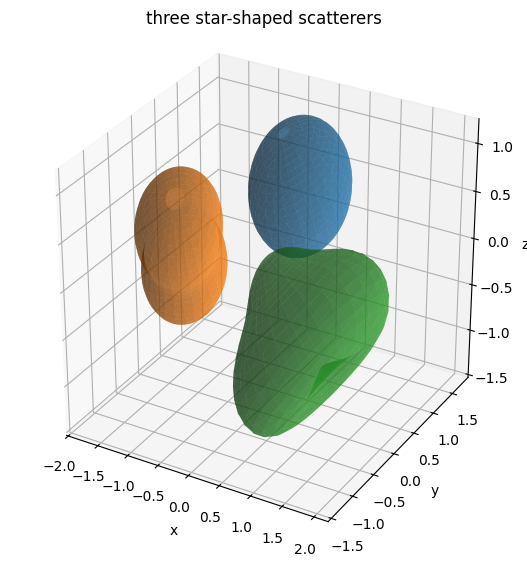

In [8]:
Nbfin, qfin = 8, 24
coeffs = coeffs8   # reuse the base solve

# 3-D sketch of the three surfaces
def body_mesh(shape, C, Q, nth=28, nph=56):
    th = np.linspace(0, np.pi, nth); ph = np.linspace(-np.pi, np.pi, nph)
    TH, PH = np.meshgrid(th, ph, indexing='ij')
    yl, _, _ = _geometry(shape, TH.ravel(), PH.ravel())
    yg = C + yl @ Q.T
    return [yg[:, i].reshape(nth, nph) for i in range(3)]

fig = plt.figure(figsize=(6.4, 5.6))
ax3 = fig.add_subplot(111, projection='3d')
cols = ['tab:orange', 'tab:green', 'tab:blue']
for (shape, C, Q), col in zip(bodies, cols):
    X, Y, Z = body_mesh(shape, C, Q)
    ax3.plot_surface(X, Y, Z, color=col, alpha=0.55, linewidth=0, shade=True)
ax3.set_box_aspect((1, 1, 1)); ax3.set_title('three star-shaped scatterers')
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('z')
plt.tight_layout(); plt.show()

In [9]:
# best-fit plane through the three centers
C3 = np.array([b[1] for b in bodies])
cen = C3.mean(0)
_, _, Vt = np.linalg.svd(C3 - cen)
e1, e2, normal = Vt[0], Vt[1], Vt[2]

ng, span = 200, 3.2
gg = np.linspace(-span, span, ng)
U1, U2 = np.meshgrid(gg, gg)
pts_f = cen + U1.ravel()[:, None] * e1 + U2.ravel()[:, None] * e2

t0 = time.time()
Uf = sm.total_field(pts_f, bodies, coeffs, Nbfin, k, quad_order=qfin, band=0.35)
t_field = time.time() - t0
print(f"field on {ng}x{ng} in-plane grid: {t_field:.1f} s "
      f"({np.mean(np.isnan(Uf)) * 100:.1f}% interior)")
Uf = Uf.reshape(ng, ng)

field on 200x200 in-plane grid: 44.2 s (12.0% interior)


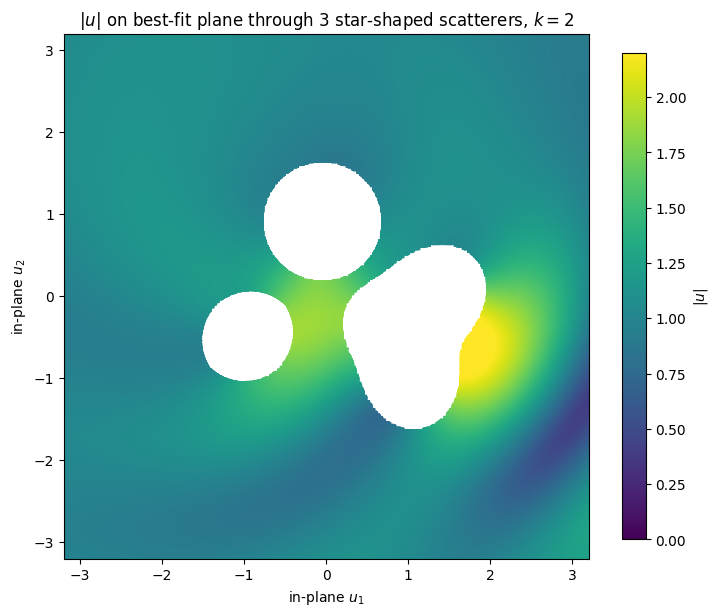

In [10]:
fig, ax = plt.subplots(figsize=(7.4, 6.4))
pc = ax.pcolormesh(U1, U2, np.abs(Uf), cmap='viridis', shading='gouraud',
                   vmin=0.0, vmax=2.2, rasterized=True)
# outline: intersect each surface with the plane via a 0-level contour of the
# signed distance to the plane, drawn in the in-plane (u1,u2) coordinates
for (shape, C, Q) in bodies:
    th = np.linspace(0, np.pi, 160); ph = np.linspace(-np.pi, np.pi, 320)
    TH, PH = np.meshgrid(th, ph, indexing='ij')
    yl, _, _ = _geometry(shape, TH.ravel(), PH.ravel())
    yg = C + yl @ Q.T
    v = yg - cen
    h = v @ normal
    u1p = v @ e1; u2p = v @ e2
    ax.tricontour(u1p, u2p, h, levels=[0.0], colors='w', linewidths=1.4)
ax.set_aspect('equal'); ax.set_xlabel('in-plane $u_1$'); ax.set_ylabel('in-plane $u_2$')
ax.set_title(f'$|u|$ on best-fit plane through 3 star-shaped scatterers, $k={k:g}$')
fig.colorbar(pc, ax=ax, shrink=0.85, label='$|u|$')
fig.tight_layout(); plt.show()

In [11]:
print(f"total notebook runtime: {time.time() - t_start:.1f} s")

total notebook runtime: 163.1 s
